<a href="https://colab.research.google.com/github/tec03/continuous_learning/blob/main/80_probability_ai_story.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Measuring Uncertainty in AI Models: The Statistical Pipeline Behind AI

## From Probability and Statistics to Random Forests

---

### Learning Goal

> Modern AI is not just about making predictions.
>
>> is about making predictions while quantifying uncertainty.  

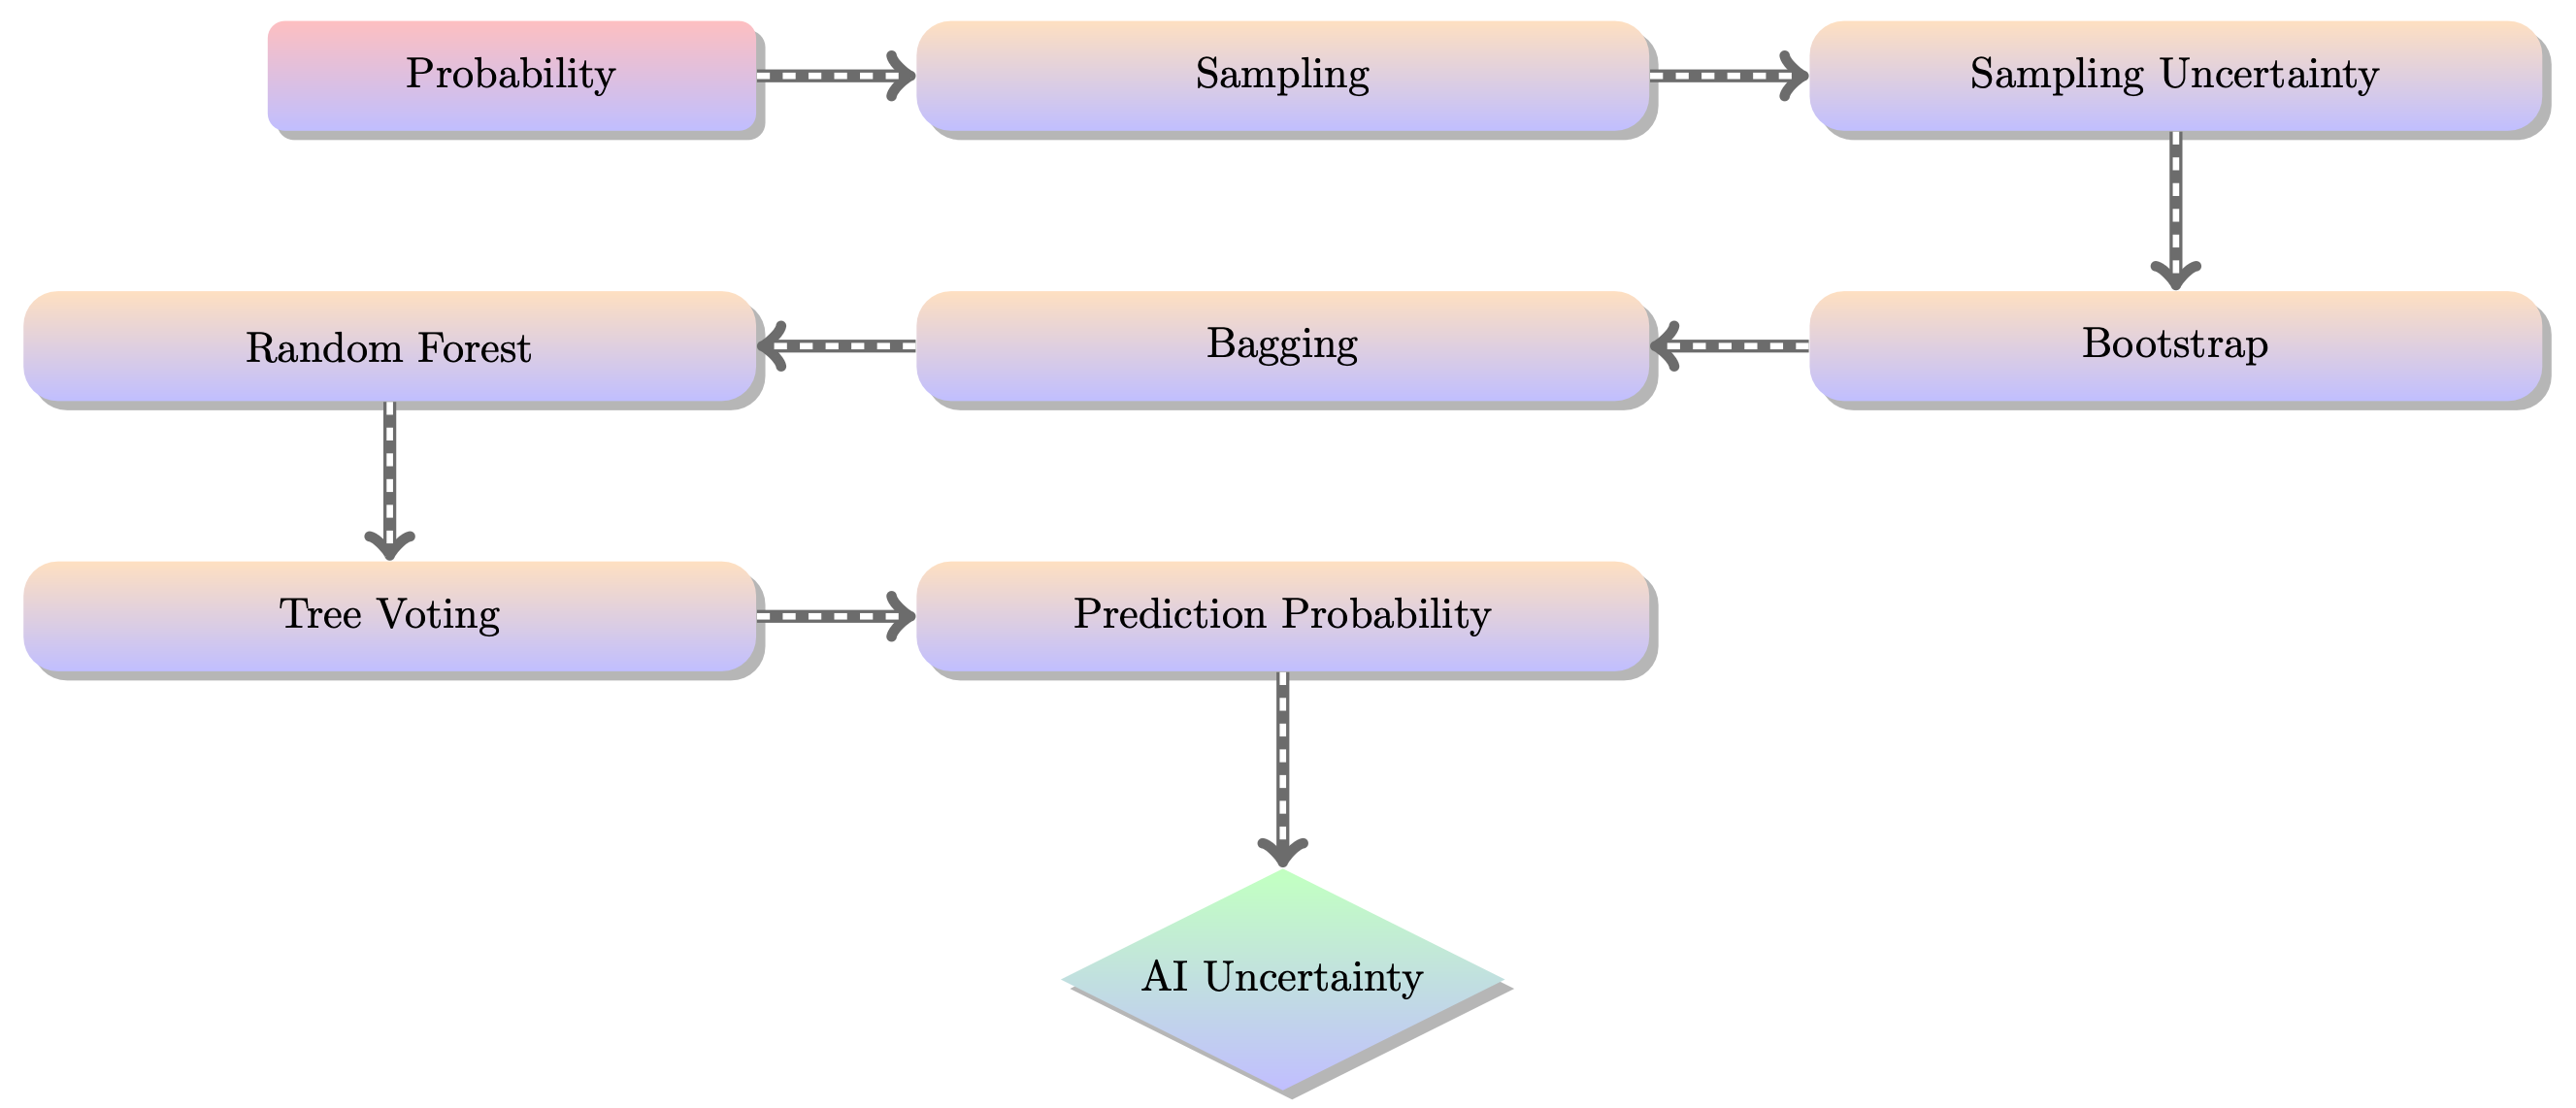

## 1. Will it rain tomorrow?

Nobody knows with complete certainty.

Similarly, AI systems face questions such as:

- Will a student pass an exam?
- Will a customer buy a product?
- Is this email spam?
- Does this medical image indicate a disease?

These questions involve uncertainty.

Therefore:

> AI is fundamentally about making decisions under uncertainty.

This naturally leads us to probability.

---

## 2. Why Do We Need Probability?

Suppose we want to know:

> What percentage of students in a university drink coffee daily?

The university has 20,000 students.

Asking every student may be expensive and time-consuming.

Instead, we select a sample.

For example:

- Sample size = 100 students
- Coffee drinkers = 65 students

Estimated probability:

$$
P(\text{Coffee}) = \frac{65}{100} = 0.65
$$

So we estimate that approximately 65% of students drink coffee.

But there is a question:

> What if we had selected a different 100 students?

Maybe the estimate becomes:

- 62%
- 68%
- 71%

Different samples produce different results.

---

## 3. Sampling Creates Uncertainty

Imagine repeatedly drawing samples of 100 students from the same university.

| Sample | Estimated Coffee Drinkers |
|----------|----------|
| Sample 1 | 65% |
| Sample 2 | 68% |
| Sample 3 | 61% |
| Sample 4 | 72% |

Which estimate is correct?

The answer is:

> All of them.

- Each sample is a valid representation of the population.

The variation among these estimates is called: - *Sampling Uncertainty*

  - Because we never observe the entire population, uncertainty is unavoidable.

This idea forms the foundation of statistical inference.

---

## 4. The Sampling Distribution

Suppose we repeat the sampling process thousands of times.

Each sample produces a different estimate.

The collection of all these estimates forms a: *Sampling Distribution*.

The sampling distribution tells us:

- How much estimates vary
- How confident we should be
- How uncertain our conclusions are

Many AI algorithms rely on this statistical concept, even if it is not immediately visible.

---


## 5. Bootstrap: Creating New Samples from One Sample

Now suppose we have only one dataset.

Question:

> How can we estimate uncertainty without collecting more data?

Statisticians developed a clever technique called: *Bootstrap Sampling*.

The idea is simple:

1. Start with the original sample.
2. Randomly draw observations from it.
3. Draw **with replacement**.
4. Create a new dataset of the same size.

Example:

Original sample:
```text
A B C D E
```

Bootstrap sample:
```text
A A D E B
```

Another bootstrap sample:
```text
C E E B A
```

Another bootstrap sample:
```text
D D D C A
```

Notice:
- Some observations appear multiple times.
- Some observations disappear.

This process mimics drawing new samples from the population.

---

### Why Bootstrap Works

Bootstrap creates many alternative versions of reality using only one dataset.

Each bootstrap sample is slightly different.

Therefore:

> Bootstrap allows us to estimate uncertainty without collecting additional data.

This idea became one of the most important techniques in modern statistics.

---

## 6. From Bootstrap to Machine Learning

Now consider a new question.

Instead of calculating a mean from each bootstrap sample:

> What if we train a machine learning model on each bootstrap sample?

This idea led to: *Bagging*.

Bagging stands for: *Bootstrap Aggregating*.

Each model learns from a slightly different dataset.



The process is:



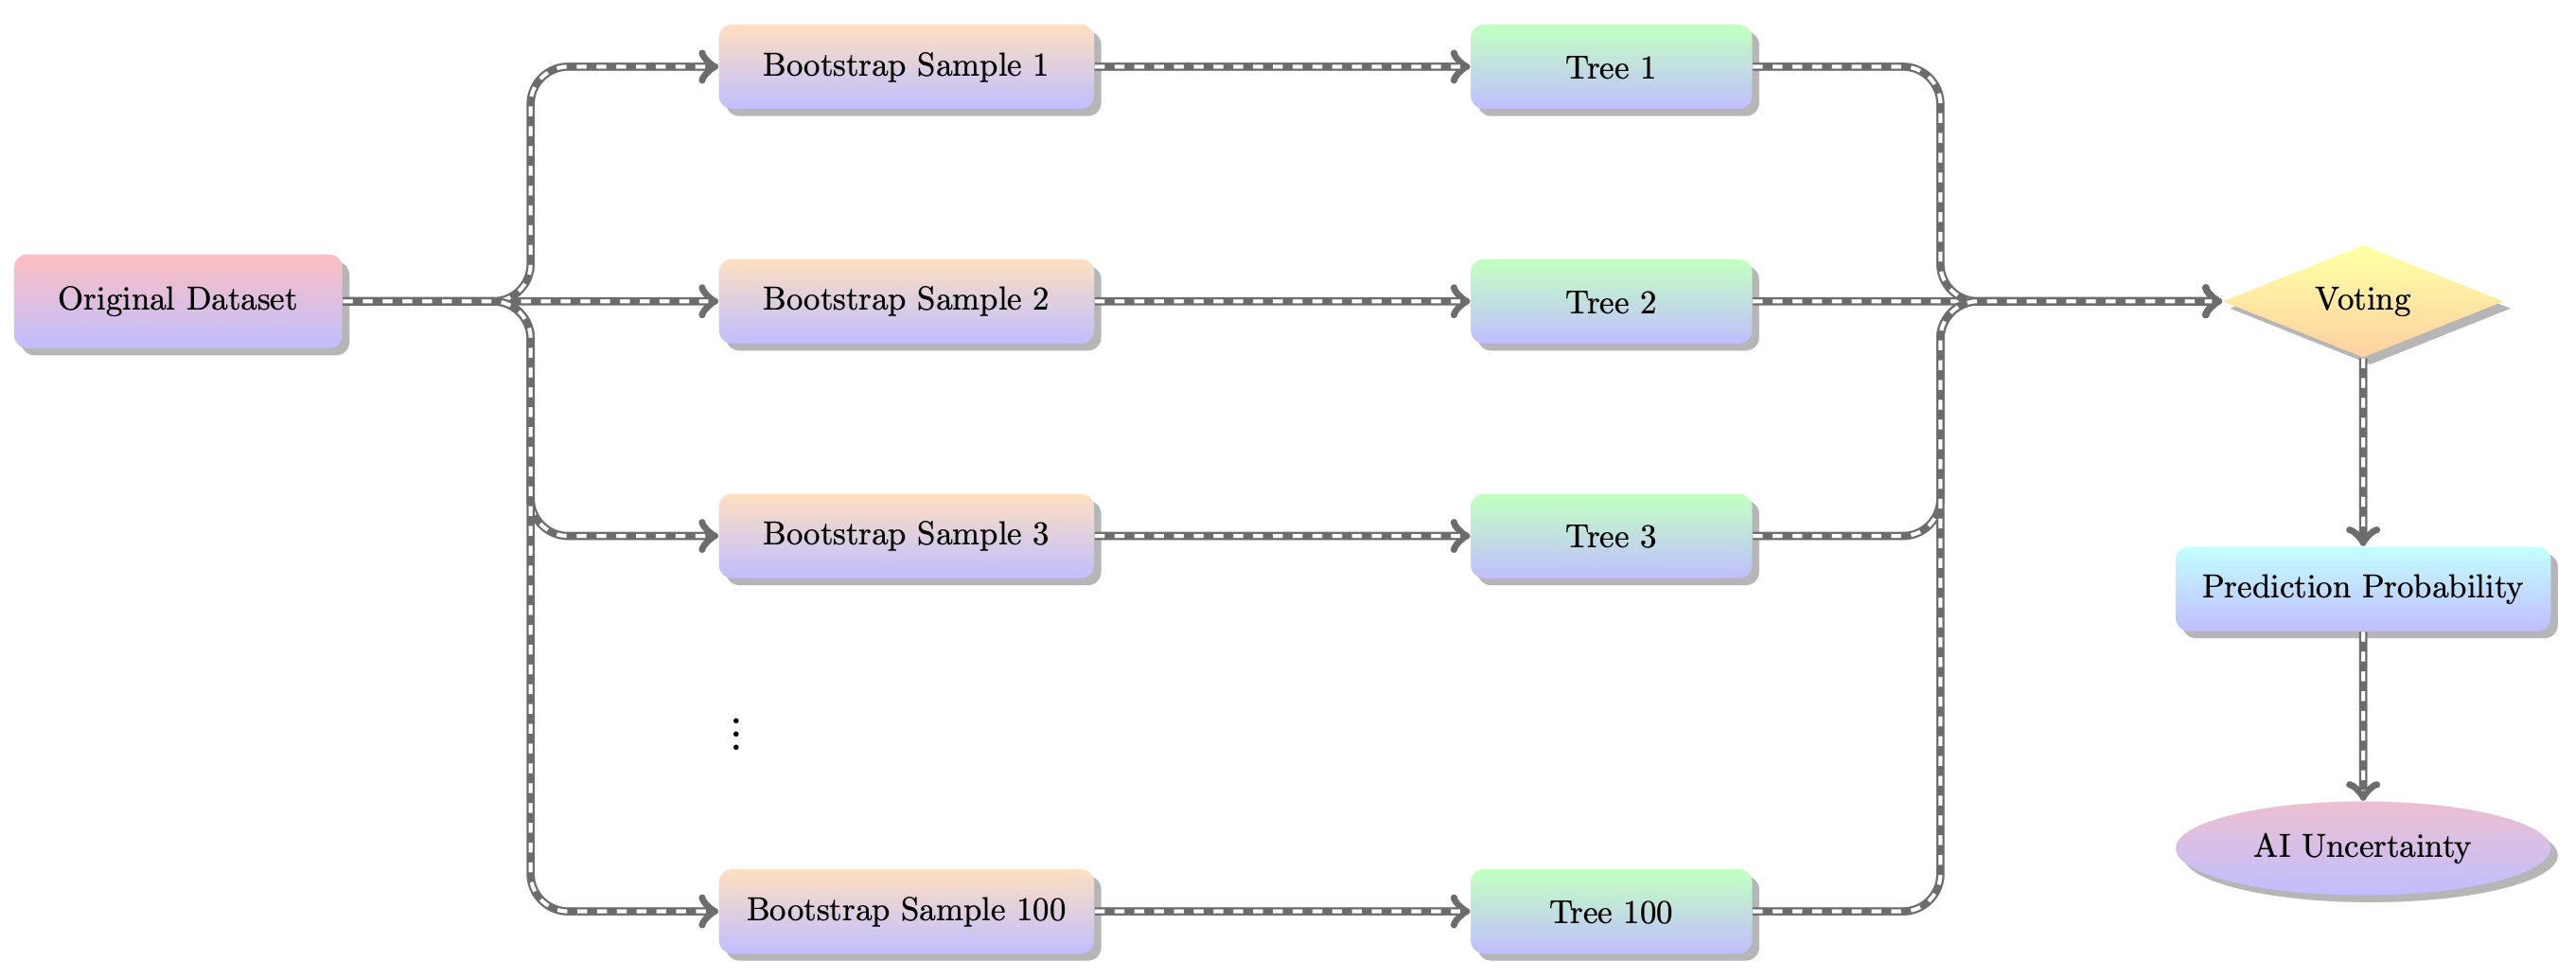

### Voting

Each tree gives its opinion.

```text
Tree 1  : Pass
Tree 2  : Pass
Tree 3  : Fail
...
Tree 100 : Pass
```

Now count the votes.

```text
Pass = 83 votes
Fail = 17 votes
```

The majority vote becomes the final prediction.

```text
Prediction = Pass
```

### Convert Votes into Probabilities

The votes can be converted into probabilities.

```text
P(Pass) = 83 / 100 = 0.83

P(Fail) = 17 / 100 = 0.17
```

In Python:

```python
rf.predict_proba(X_test)
```

Possible output:

```python
[0.83, 0.17]
```

Interpretation:

> The Random Forest behaves as if it is 83% confident that the observation belongs to the "Pass" class.

## 7. Random Forest: Bagging with Decision Trees

Random Forest extends the bagging idea.

Instead of building one decision tree:

> Build many decision trees.

Each tree is trained on a different bootstrap sample.

Example:

```python
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    bootstrap=True,
    random_state=42
)

rf.fit(X_train, y_train)
```

```python
n_estimators=100  # Build 100 decision trees.
bootstrap=True # Each tree receives a different bootstrap sample.
```

Thus:

- Tree 1 sees one version of reality.
- Tree 2 sees another version.
- Tree 3 sees another version.

Each tree learns slightly differently.


```python
random_state=42
```

This fixes the random number generator.

As a result:

- The same bootstrap samples are generated every time.
- The experiment becomes reproducible.

This is useful for teaching, debugging, and research.

---

## 8. Why Many Trees Are Better Than One

Imagine asking one faculty member:

> Will this student pass?

The answer may be wrong.

Now ask 100 faculty members.

Most likely:

- Individual errors cancel out.
- Collective judgment becomes more reliable.

Random Forest works in a similar way.

Each tree provides an opinion.

Example:

```text
Tree 1 : Yes
Tree 2 : Yes
Tree 3 : No
Tree 4 : Yes
...
```

The forest combines all opinions.

---



## 9. Majority Voting

The final prediction is obtained through voting.

Example:

```text
Class A : 78 votes
Class B : 22 votes
```

Final prediction:

```text
Class A
```

Because it received the majority vote.

Prediction:

```python
pred = rf.predict(X_test)
```

---

## 10. Where Does Uncertainty Appear?



> The more disagreement among trees, the greater the uncertainty.



### Confidence and Uncertainty

Now consider two scenarios.

#### Scenario A

```text
Pass = 98 votes
Fail = 2 votes
```

```text
Confidence = 98%
Uncertainty = 2%
```

Almost every tree agrees.

The model is highly confident.


#### Scenario B

```text
Pass = 51 votes
Fail = 49 votes
```

```text
Confidence = 51%
Uncertainty = 49%
```

The trees strongly disagree.

The model is uncertain.



1. Random Forest does more than make predictions.

2. It also tells us how strongly the trees agree with each other.

```text
More Agreement  ->  Higher Confidence ->  Lower Uncertainty

Less Agreement  ->  Lower Confidence  ->  Higher Uncertainty
```
---

## 11. Probability from Random Forest

Instead of only counting votes, we can convert votes into probabilities.

Suppose:

```text
83 trees vote for Class A
17 trees vote for Class B
```

Estimated probabilities:

$$
P(A) = 0.83
$$

$$
P(B) = 0.17
$$

In Python:

```python
rf.predict_proba(X_test)
```

Possible output:

```text
[0.83, 0.17]
```

Interpretation:

> The forest behaves as if it is 83% confident that the observation belongs to Class A.

---

## 12. Measuring AI Uncertainty

Prediction alone is not enough.

Consider two models.

### Model A

```text
Prediction = Positive
Confidence = 99%
```

---

### Model B

```text
Prediction = Positive
Confidence = 51%
```

Both predictions may be correct.

However:

- Model A is highly confident.
- Model B is uncertain.

Accuracy treats them equally.

Uncertainty does not.

This is why modern AI systems often report:

- Prediction
- Probability
- Confidence
- Uncertainty

Together.

---





###  Prediction, Probability, Confidence, and Uncertainty - Together !!!

Suppose we have a Random Forest with 100 trees trying to predict whether a student will pass an exam.

### Case A

Votes:

```text
Pass = 99
Fail = 1
```


**1. Prediction**

The final class selected by the model.

```text
Prediction = Pass
```


**2. Probability**

The fraction of trees supporting each class.

```text
P(Pass) = 99/100 = 0.99

P(Fail) = 1/100 = 0.01
```


**3. Confidence**

How strongly the model supports its prediction.

```text
Confidence = 99%
```

because the winning class received 99% of the votes.


**4. Uncertainty**

One simple interpretation is:

```text
Uncertainty = 1 − Confidence
```

Therefore:

```text
Uncertainty = 1 − 0.99 = 0.01
```
or

```text
Uncertainty = 1%
```


### Case B

Votes:

```text
Pass = 51
Fail = 49
```


**1. Prediction**

The majority still wins.

```text
Prediction = Pass
```

Note: The prediction is identical to Case A.


**2. Probability**

```text
P(Pass) = 0.51

P(Fail) = 0.49
```


**3. Confidence**

```text
Confidence = 51%
```

The forest barely agrees.



**4. Uncertainty**

```text
Uncertainty = 1 − 0.51 = 49%
```




<table>
<tr>
<td valign="top">

### Case A

| Quantity | Value |
|----------|--------|
| Prediction | Pass |
| Probability | 0.99 |
| Confidence | 99% |
| Uncertainty | 1% |

</td>

<td width="50"></td>

<td valign="top">

### Case B

| Quantity | Value |
|----------|--------|
| Prediction | Pass |
| Probability | 0.51 |
| Confidence | 51% |
| Uncertainty | 49% |

</td>
</tr>
</table>

### Why Accuracy Cannot Distinguish A and B

>> *Suppose the true answer is: $Pass$*

Then both models are correct.

Accuracy says:

```text
Model A = Correct

Model B = Correct
```

Accuracy treats them equally.

However:

| Metric      | Model A | Model B |
| ----------- | ------- | ------- |
| Prediction  | Pass    | Pass    |
| Accuracy    | Correct | Correct |
| Confidence  | 99%     | 51%     |
| Uncertainty | 1%      | 49%     |

Clearly these are not the same decision.


#### What a Doctor Would Prefer? - Imagine an AI predicting cancer.

#### Model A

```text
Prediction = Cancer

Probability = 0.99

Confidence = 99%

Uncertainty = 1%
```

A doctor may trust this result.


#### Model B

```text
Prediction = Cancer

Probability = 0.51

Confidence = 51%

Uncertainty = 49%
```

A doctor would probably order more tests.


## The Big Idea

- Prediction tells us: `What does the model think?`

- Probability tells us:`How likely is each class?`

- Confidence tells us:`How strongly does the model believed it was right`

- Uncertainty tells us:`How much doubt remains in the prediction?`

- Accuracy tells us :`Whether the model was right in reality.`


These are related, but they are not the same thing. This is why modern AI systems should not only say:

```text
Prediction = Pass
```

but rather:

```text
Prediction = Pass
Probability = 0.99
Confidence = 99%
Uncertainty = 1%
```

because a decision-maker often cares more about **how certain the model is** than about the prediction itself.



## 13. Evaluating the Model

After making predictions:

```python
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, pred)
print(accuracy)
```

Accuracy measures:

$$
\text{Accuracy}
=
\frac{\text{Correct Predictions}}
{\text{Total Predictions}}
$$

However:

> Accuracy alone does not tell us how certain the model is.

Therefore, uncertainty estimation is becoming increasingly important in modern AI.

---

# Key Takeaways

1. AI operates in an uncertain world.
2. Probability helps quantify uncertainty.
3. Sampling introduces variability.
4. Bootstrap creates multiple datasets from a single dataset.
5. Bagging trains multiple models on bootstrap samples.
6. Random Forest applies bagging to decision trees.
7. Trees vote to make predictions.
8. The distribution of votes provides probabilities.
9. Probabilities provide a measure of uncertainty.
10. Modern AI is not only about prediction—it is also about confidence and uncertainty.

---

# Final Thought

When we write:

```python
bootstrap=True
```

we are not merely setting a parameter.

We are applying more than a century of statistical thinking about:

- Probability
- Sampling
- Variability
- Uncertainty

Modern AI stands on the foundations built by classical statistics.
